# Load QED-CCSD Data
This data considers the energy of the meta and ortho intermediates with a fixed geometry and different orientations of the field (by $\theta$ and $\phi$ values), which is equivalent to a rigid rotation about the field axis.

The following cell will load and interpolate this data on a $\theta,\phi$ grid.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [2]:
### THIS CELL READS FROM ORTHO, META, AND NITRO!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def load_and_analyze_dataset(df, dataset_name, n_grid_points=24):
    """
    Perform interpolation and accuracy analysis on a molecular energy dataset.
    """
    print(f"\n{'='*60}")
    print(f"Processing: {dataset_name}")
    print(f"{'='*60}")
    
    # Extract values
    theta_vals = df['theta'].values
    phi_vals = df['phi'].values
    values = df['value'].values
    
    print(f"Data points: {len(values)}")
    print(f"Theta range: [{theta_vals.min():.4f}, {theta_vals.max():.4f}]")
    print(f"Phi range: [{phi_vals.min():.4f}, {phi_vals.max():.4f}]")
    print(f"Value range: [{values.min():.6e}, {values.max():.6e}]")
    
    # Create pivot table for internal tracking
    pivot_df = df.pivot_table(index='theta', columns='phi', values='value')
    pivot_df.index = pivot_df.index.round(4)
    pivot_df.columns = pivot_df.columns.round(4)
    
    # Create fine grid for interpolation
    phi_grid = np.linspace(phi_vals.min(), phi_vals.max(), n_grid_points)
    theta_grid = np.linspace(theta_vals.min(), theta_vals.max(), n_grid_points)
    PH, TH = np.meshgrid(phi_grid, theta_grid)
    
    # Perform interpolation on grid
    grid_values = griddata((phi_vals, theta_vals), values, 
                          (PH, TH), method='linear')
    
    # Test accuracy: interpolate at original data points
    interpolated_at_original = griddata((phi_vals, theta_vals), values,
                                       (phi_vals, theta_vals), method='linear')
    
    # Calculate errors
    absolute_errors = np.abs(values - interpolated_at_original)
    relative_errors = np.abs((values - interpolated_at_original) / values) * 100
    
    # Remove NaN values (edge points)
    valid_mask = ~np.isnan(interpolated_at_original)
    absolute_errors_clean = absolute_errors[valid_mask]
    relative_errors_clean = relative_errors[valid_mask]
    values_clean = values[valid_mask]
    
    # Print statistics
    print(f"\nInterpolation Accuracy Assessment:")
    print(f"{'-'*60}")
    print(f"Successfully interpolated: {np.sum(valid_mask)}/{len(values)}")
    print(f"\nAbsolute Error Statistics:")
    print(f"  Mean: {np.mean(absolute_errors_clean):.6e}")
    print(f"  Std:  {np.std(absolute_errors_clean):.6e}")
    print(f"  Max:  {np.max(absolute_errors_clean):.6e}")
    
    # Visualization for this specific dataset
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'{dataset_name} - Interpolation Analysis', fontsize=16, fontweight='bold')
    
    # 1. Original data scatter
    scatter = axes[0, 0].scatter(df['phi'], df['theta'], c=df['value'], 
                                cmap='viridis', s=50, edgecolors='black', linewidth=0.5)
    axes[0, 0].set_xlabel('Phi (degrees)')
    axes[0, 0].set_ylabel('Theta (degrees)')
    axes[0, 0].set_title('Original Data Points')
    plt.colorbar(scatter, ax=axes[0, 0], label='Energy')
    
    # 2. Interpolated surface
    contour = axes[0, 1].contourf(PH, TH, grid_values, levels=20, cmap='viridis')
    axes[0, 1].set_xlabel('Phi (degrees)')
    axes[0, 1].set_ylabel('Theta (degrees)')
    axes[0, 1].set_title('Interpolated Surface')
    plt.colorbar(contour, ax=axes[0, 1], label='Energy')
    
    # 3. Absolute error distribution
    axes[1, 0].hist(absolute_errors_clean, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1, 0].set_xlabel('Absolute Error')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Absolute Errors')
    
    # 4. Error vs original value
    axes[1, 1].scatter(values_clean, absolute_errors_clean, alpha=0.5, s=20, color='steelblue')
    axes[1, 1].set_xlabel('Original Energy Value')
    axes[1, 1].set_ylabel('Absolute Error')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'dataset_name': dataset_name,
        'PH': PH, 'TH': TH,
        'grid_values': grid_values,
        'mean_abs_error': np.mean(absolute_errors_clean),
        'mean_rel_error': np.mean(relative_errors_clean),
        'phi_grid' : phi_grid,
        'theta_grid' : theta_grid,
        'n_valid': np.sum(valid_mask),
        'n_total': len(values)
    }



Loading META dataset...
Loading ORTHO dataset...
Loading PARA dataset...
Loading NITRO dataset...
Maximum Energy Difference (meta-ortho): 23.751959308318185
Minimum Energy Difference (meta-ortho): -27.377742182513977
Maximum Energy Difference (meta-para): 14.225081655218219
Minimum Energy Difference (meta-para): -37.768492707367194

Processing: META CCSD
Data points: 576
Theta range: [0.0000, 180.0000]
Phi range: [0.0000, 360.0000]
Value range: [-3.007841e+03, -3.007754e+03]

Interpolation Accuracy Assessment:
------------------------------------------------------------
Successfully interpolated: 576/576

Absolute Error Statistics:
  Mean: 1.578984e-15
  Std:  2.674968e-14
  Max:  4.547474e-13


/var/folders/dp/63x0n7nd4_q9b8cbskjk1xpr0000gp/T/ipykernel_9328/3427848194.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ortho_df = pd.read_csv('CCSD_DATA/ortho_ccsd_energies.txt', delim_whitespace=True,
/var/folders/dp/63x0n7nd4_q9b8cbskjk1xpr0000gp/T/ipykernel_9328/3427848194.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  para_df = pd.read_csv('CCSD_DATA/para_ccsd_energies.txt', delim_whitespace=True,


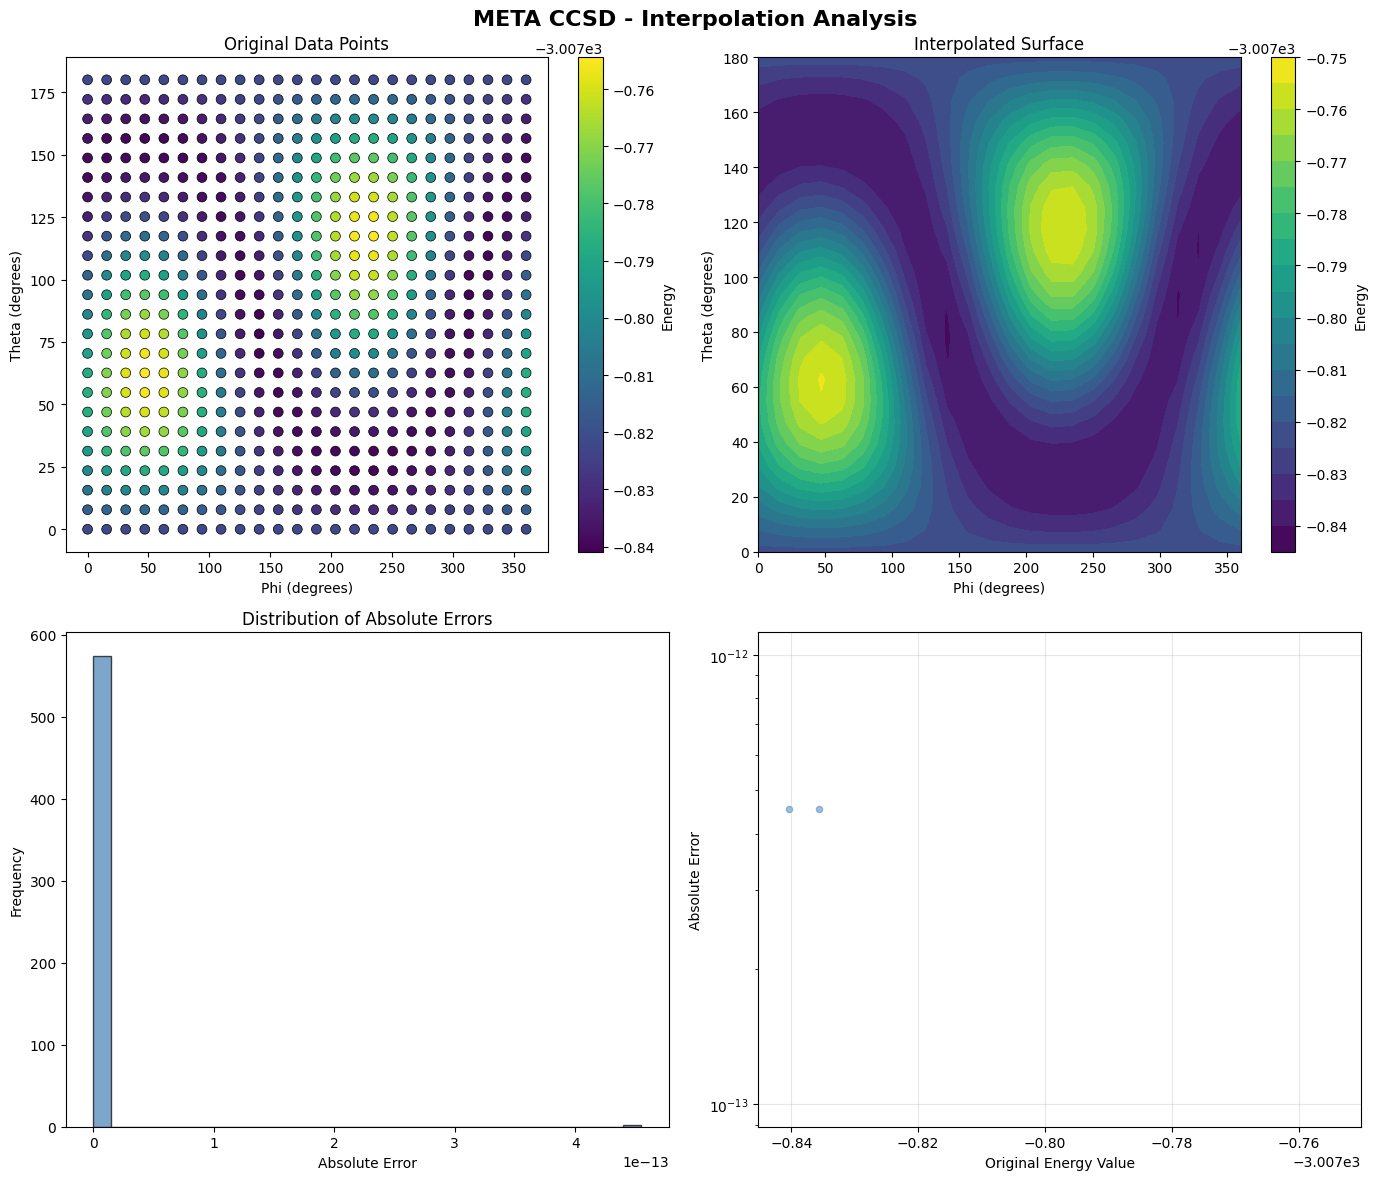


Processing: ORTHO CCSD
Data points: 576
Theta range: [0.0000, 180.0000]
Phi range: [0.0000, 360.0000]
Value range: [-3.007838e+03, -3.007778e+03]

Interpolation Accuracy Assessment:
------------------------------------------------------------
Successfully interpolated: 576/576

Absolute Error Statistics:
  Mean: 7.894919e-16
  Std:  1.893135e-14
  Max:  4.547474e-13


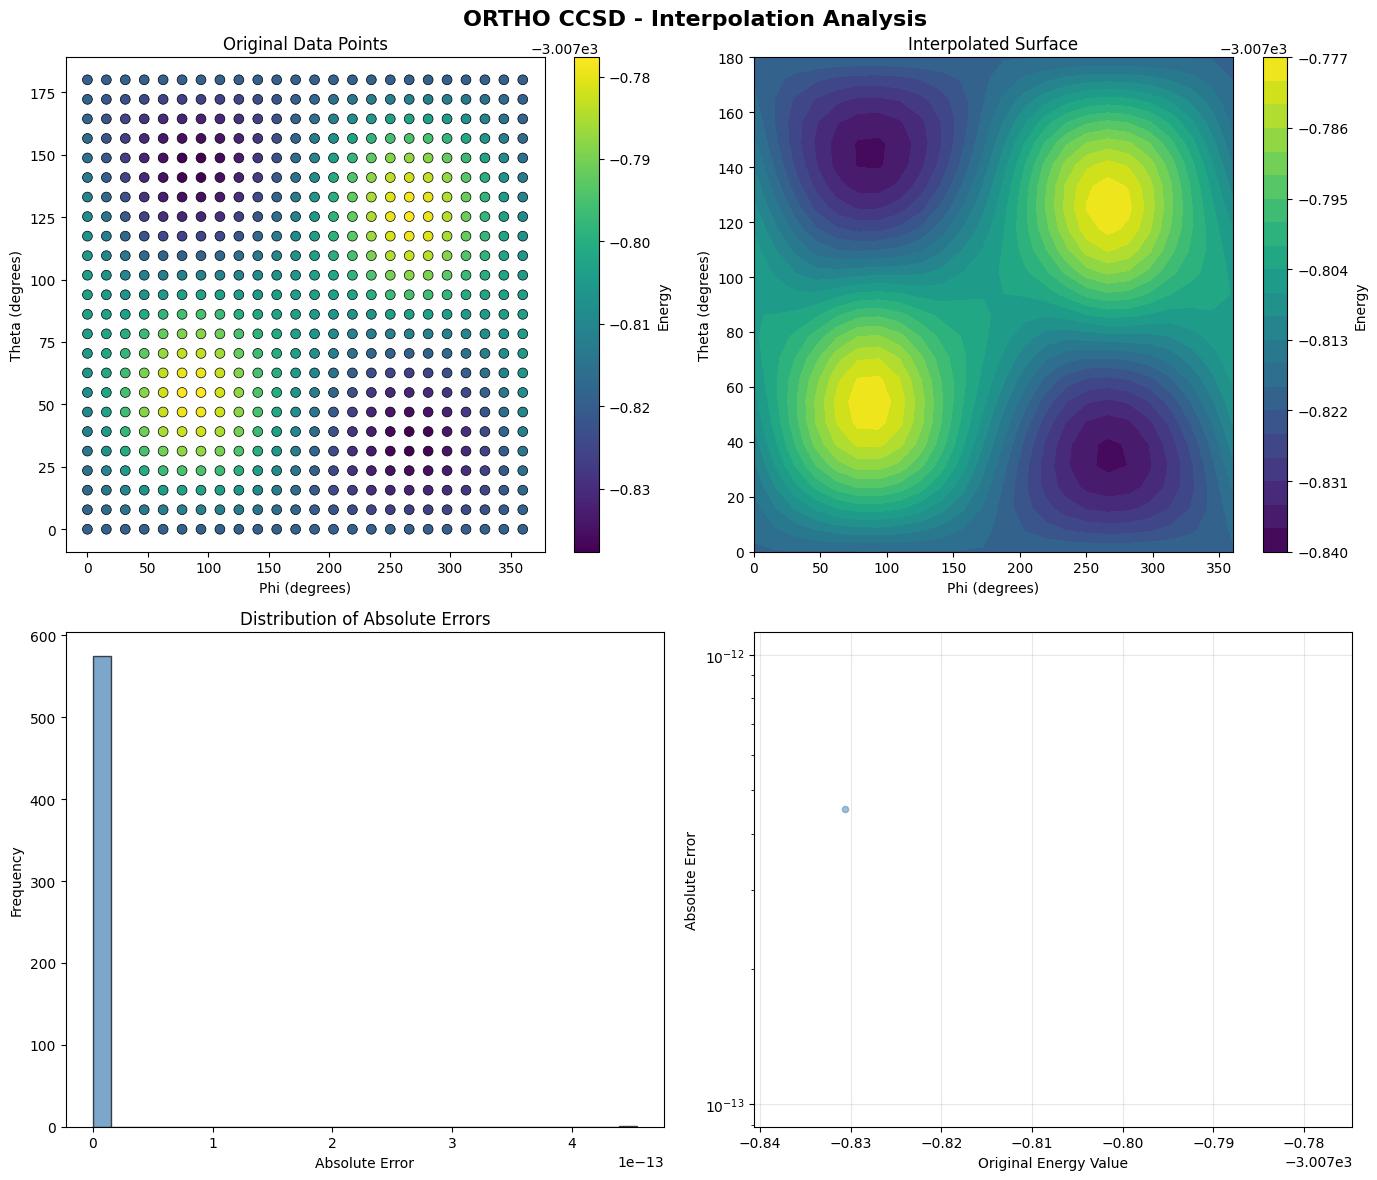


Processing: PARA CCSD
Data points: 576
Theta range: [0.0000, 180.0000]
Phi range: [0.0000, 360.0000]
Value range: [-3.007852e+03, -3.007756e+03]

Interpolation Accuracy Assessment:
------------------------------------------------------------
Successfully interpolated: 576/576

Absolute Error Statistics:
  Mean: 1.578984e-15
  Std:  2.674968e-14
  Max:  4.547474e-13


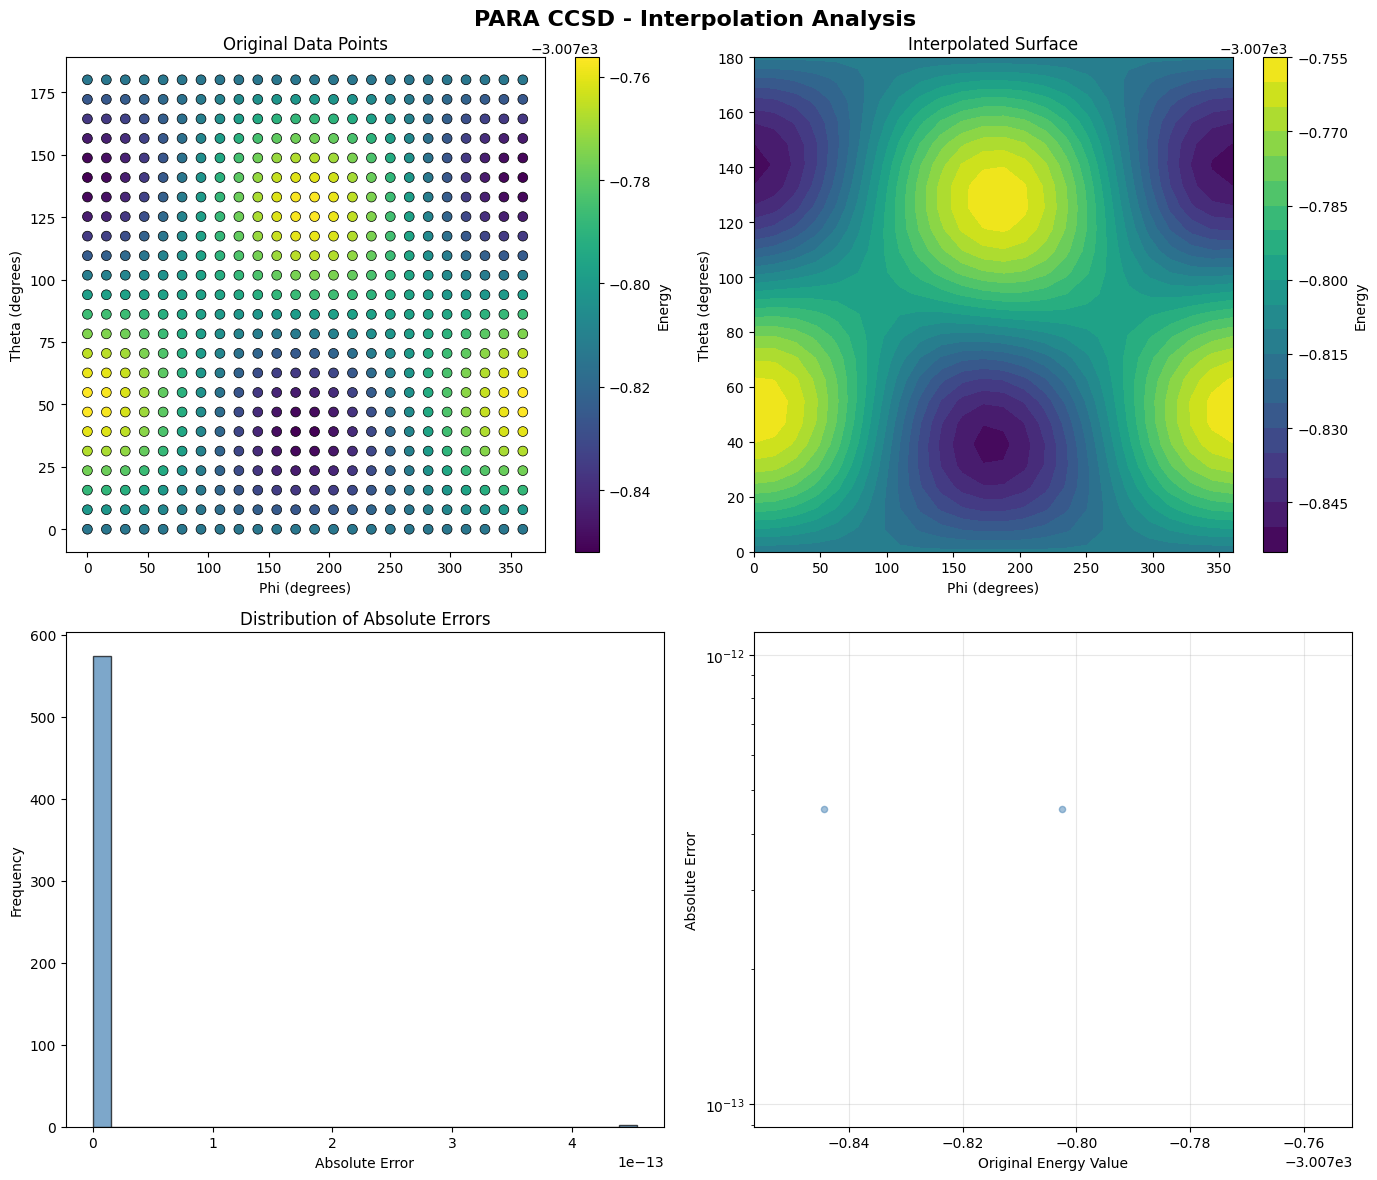


Processing: NITRO Field Scan
Data points: 625
Theta range: [0.0000, 180.0000]
Phi range: [0.0000, 360.0000]
Value range: [-4.341258e+02, -4.340787e+02]

Interpolation Accuracy Assessment:
------------------------------------------------------------
Successfully interpolated: 625/625

Absolute Error Statistics:
  Mean: 0.000000e+00
  Std:  0.000000e+00
  Max:  0.000000e+00


/var/folders/dp/63x0n7nd4_q9b8cbskjk1xpr0000gp/T/ipykernel_9328/4158096840.py:91: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[1, 1].set_yscale('log')


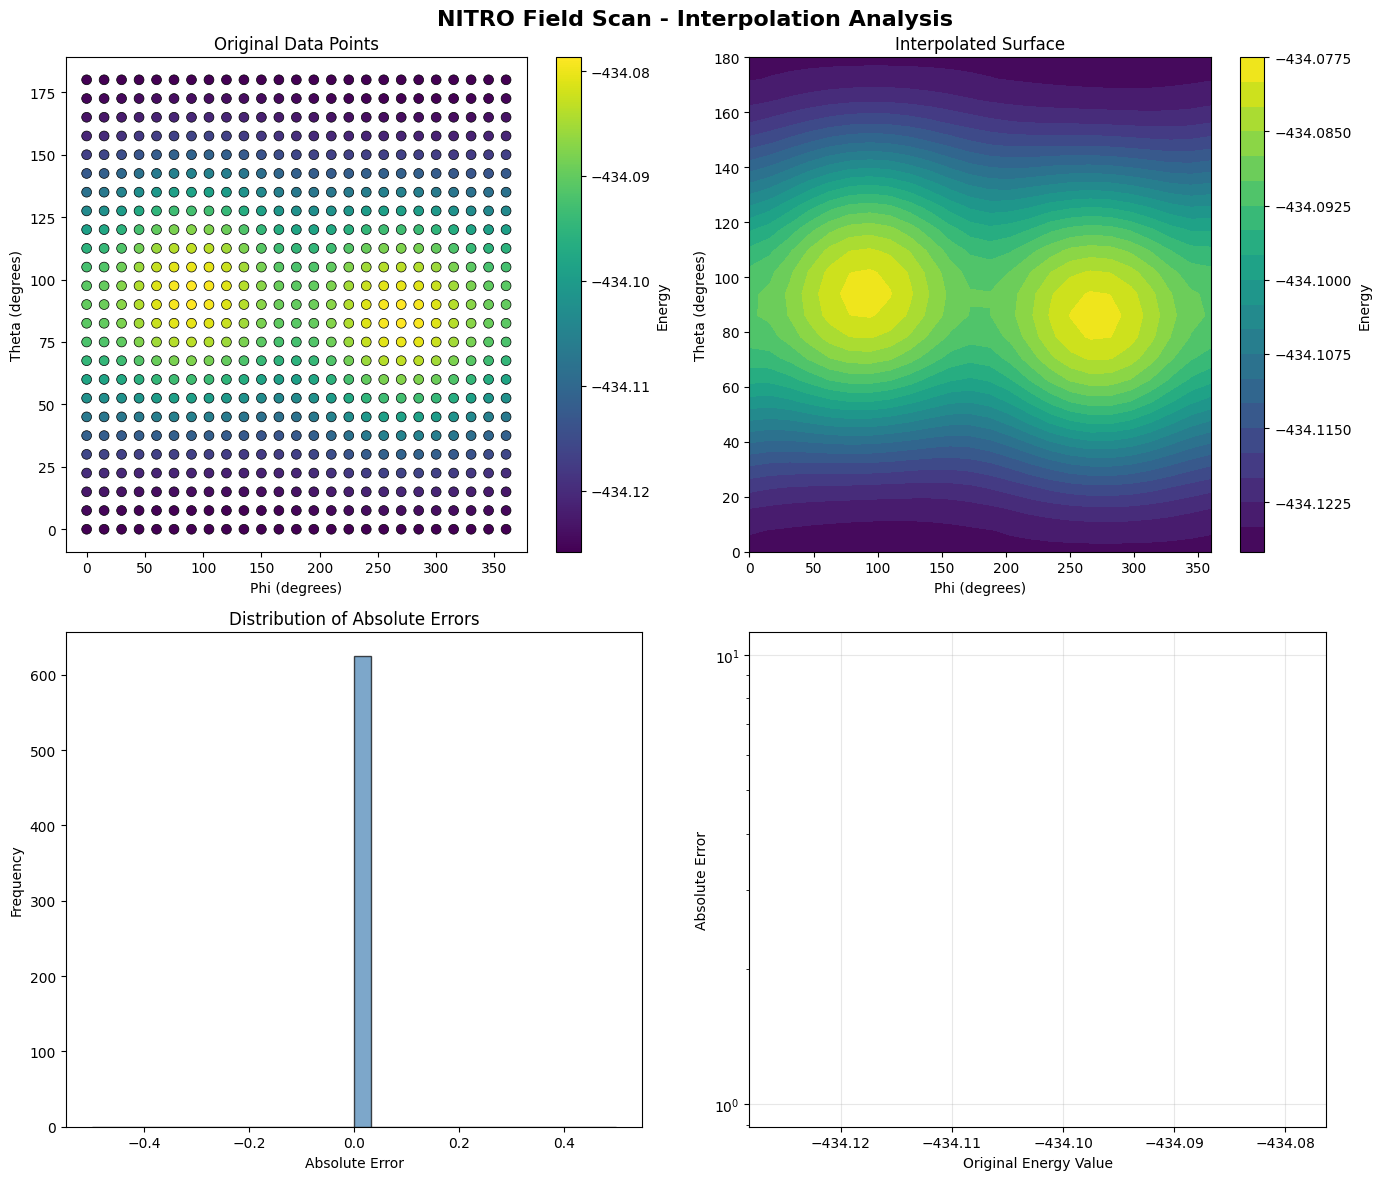


COMPARISON SUMMARY

Dataset              Points     Valid      Mean Abs Err    Mean Rel Err % 
--------------------------------------------------------------------------------
META CCSD            576        576        1.578984e-15    0.0000         
ORTHO CCSD           576        576        7.894919e-16    0.0000         
PARA CCSD            576        576        1.578984e-15    0.0000         
NITRO Field Scan     625        625        0.000000e+00    0.0000         


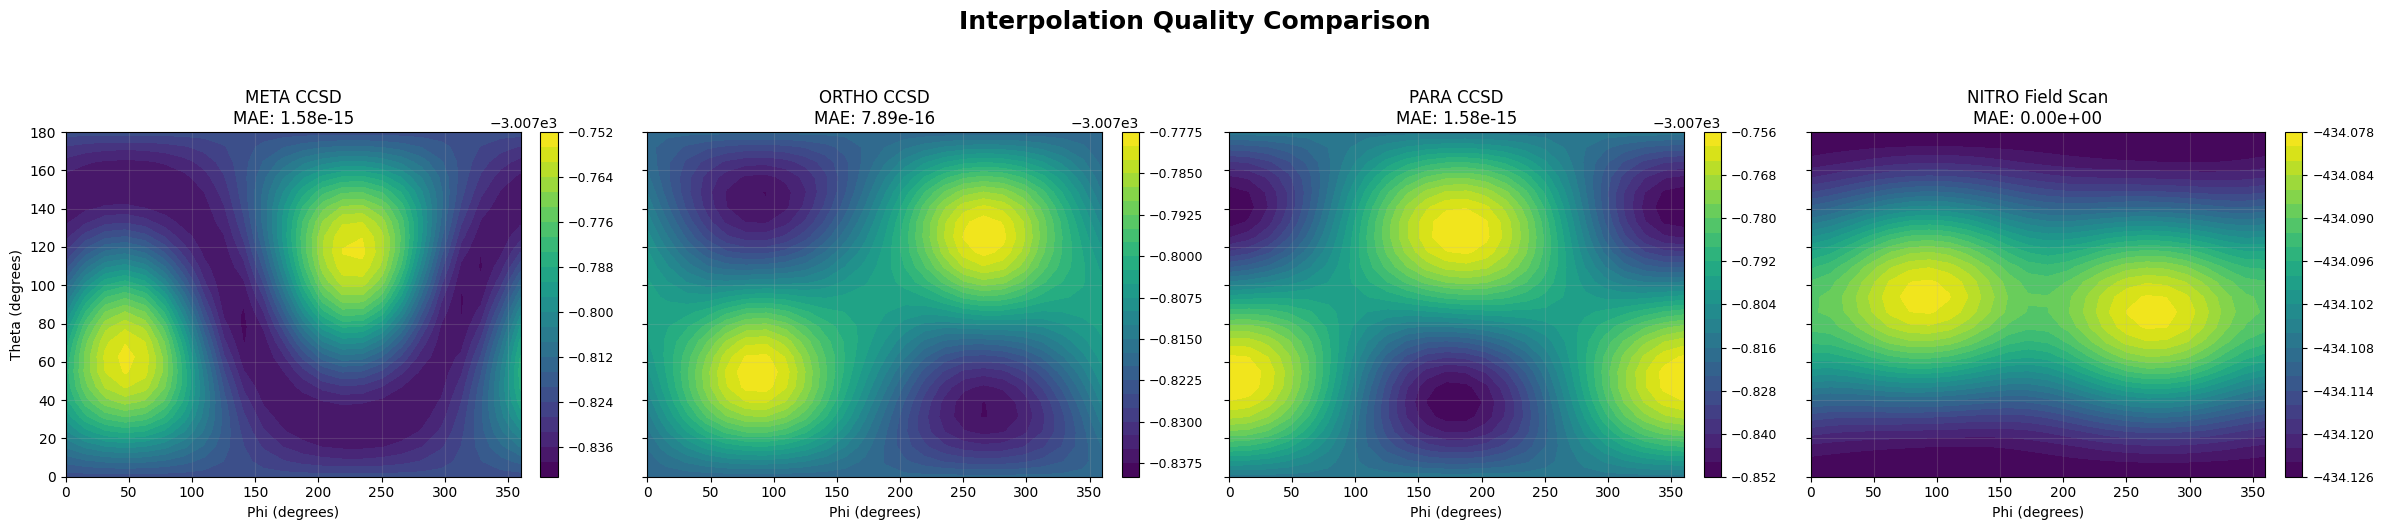


Analysis complete!


In [3]:
# ===== 1. LOAD ALL DATASETS =====

# META dataset
print("Loading META dataset...")
meta_df = pd.read_csv('CCSD_DATA/meta_ccsd_energies.txt', sep='\s+', header=None, 
                      names=['filename', 'value'])
pattern = r"theta_(.*?)_phi_(.*?)\.json"
meta_df[['theta', 'phi']] = meta_df['filename'].str.extract(pattern).astype(float)
meta_df = meta_df[['theta', 'phi', 'value']]

# ORTHO dataset
print("Loading ORTHO dataset...")
ortho_df = pd.read_csv('CCSD_DATA/ortho_ccsd_energies.txt', delim_whitespace=True,
                       header=None, names=['theta', 'phi', 'value'])

# PARA dataset
print("Loading PARA dataset...")
para_df = pd.read_csv('CCSD_DATA/para_ccsd_energies.txt', delim_whitespace=True,
                       header=None, names=['theta', 'phi', 'value'])

# NITRO dataset (NEW)
print("Loading NITRO dataset...")
nitro_df = pd.read_csv('CCSD_DATA/nitro_field_scan_results.txt', 
                       sep='\s+', 
                       comment='#', 
                       header=None, 
                       names=['theta', 'phi', 'x', 'y', 'z', 'value'])
nitro_df = nitro_df[['theta', 'phi', 'value']]

# get difference of raw data
meta_df[['theta', 'phi']] = meta_df[['theta', 'phi']].round(4)
ortho_df[['theta', 'phi']] = ortho_df[['theta', 'phi']].round(4)
para_df[['theta', 'phi']] = para_df[['theta', 'phi']].round(4)

# 1. Set theta and phi as the index for both
meta_indexed = meta_df.set_index(['theta', 'phi'])
ortho_indexed = ortho_df.set_index(['theta', 'phi'])
para_indexed = para_df.set_index(['theta', 'phi'])

# 2. Subtract the energy values
# Pandas aligns rows based on the matching (theta, phi) index
energy_diff_om = meta_indexed['value'] - ortho_indexed['value'] #< -- meta - ortho
energy_diff_pm = meta_indexed['value'] - para_indexed['value']  #<--  meta - para

# 3. Convert back to a regular DataFrame
diff_om_df = energy_diff_om.reset_index(name='energy_difference') #<-- meta - ortho
diff_pm_df = energy_diff_pm.reset_index(name='energy_difference') #<-- meta - para

max_val_om = diff_om_df['energy_difference'].max() * 627.509 #<-- meta - ortho
min_val_om = diff_om_df['energy_difference'].min() * 627.509 #<-- meta - ortho

max_val_pm = diff_pm_df['energy_difference'].max() * 627.509 #<-- meta - para
min_val_pm = diff_pm_df['energy_difference'].min() * 627.509 #<-- meta - para

print(f"Maximum Energy Difference (meta-ortho): {max_val_om}")
print(f"Minimum Energy Difference (meta-ortho): {min_val_om}")
print(f"Maximum Energy Difference (meta-para): {max_val_pm}")
print(f"Minimum Energy Difference (meta-para): {min_val_pm}")

# ===== 2. ANALYZE ALL DATASETS =====

meta_results = load_and_analyze_dataset(meta_df, "META CCSD", n_grid_points=24)
ortho_results = load_and_analyze_dataset(ortho_df, "ORTHO CCSD", n_grid_points=24)
para_results = load_and_analyze_dataset(para_df, "PARA CCSD", n_grid_points=24)
nitro_results = load_and_analyze_dataset(nitro_df, "NITRO Field Scan", n_grid_points=24)

# ===== 3. COMPARISON SUMMARY =====

print(f"\n{'='*60}")
print("COMPARISON SUMMARY")
print(f"{'='*60}")

results_list = [meta_results, ortho_results, para_results, nitro_results]

print(f"\n{'Dataset':<20} {'Points':<10} {'Valid':<10} {'Mean Abs Err':<15} {'Mean Rel Err %':<15}")
print(f"{'-'*80}")
for r in results_list:
    print(f"{r['dataset_name']:<20} {r['n_total']:<10} {r['n_valid']:<10} "
          f"{r['mean_abs_error']:<15.6e} {r['mean_rel_error']:<15.4f}")

# Dynamic plot layout
num_plots = len(results_list)
fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5), sharey=True)
fig.suptitle('Interpolation Quality Comparison', fontsize=18, fontweight='bold', y=1.05)

for i, r in enumerate(results_list):
    ax = axes[i]
    cp = ax.contourf(r['PH'], r['TH'], r['grid_values'], levels=25, cmap='viridis')
    
    # Add colorbar for energy range
    cbar = fig.colorbar(cp, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)
    
    ax.set_xlabel('Phi (degrees)')
    if i == 0: ax.set_ylabel('Theta (degrees)')
    ax.set_title(f"{r['dataset_name']}\nMAE: {r['mean_abs_error']:.2e}")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("\nAnalysis complete!")

/var/folders/dp/63x0n7nd4_q9b8cbskjk1xpr0000gp/T/ipykernel_9328/2933023043.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


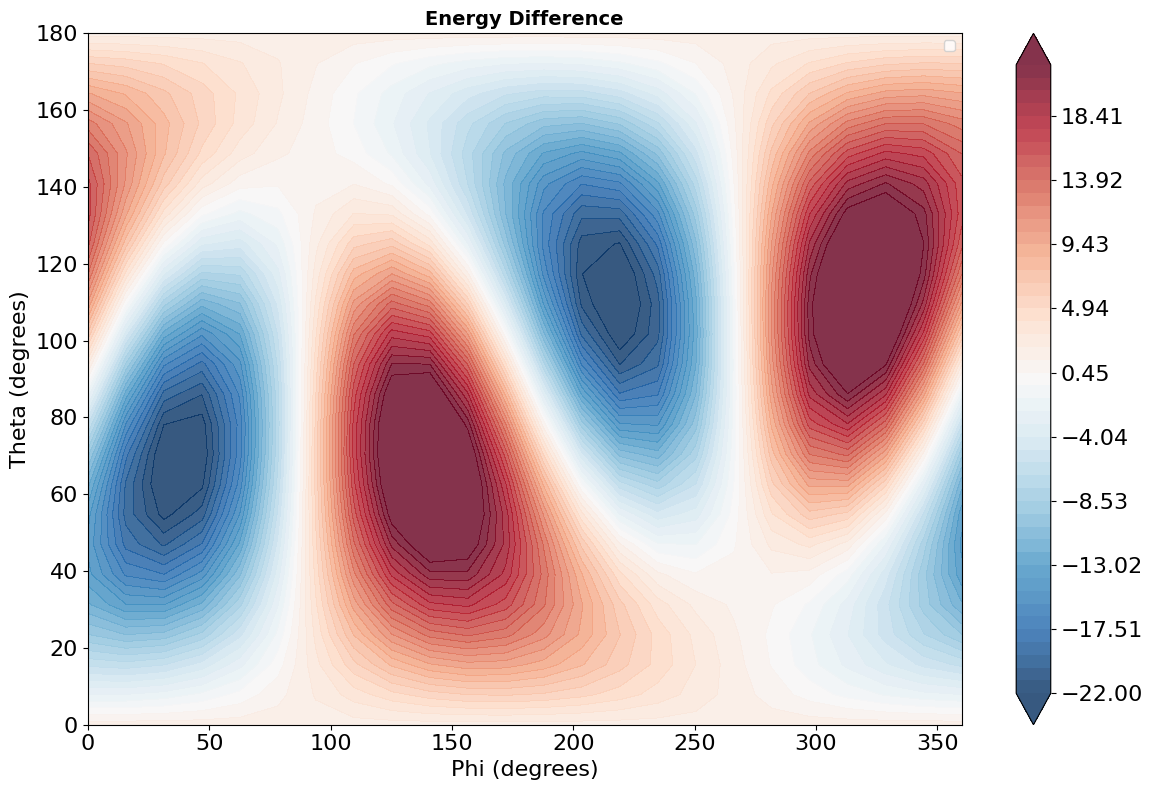


Energy Difference Statistics:
------------------------------------------------------------
Mean difference: 1.498762e+00
Std difference: 1.150976e+01
Max difference: 2.737776e+01
Min difference: -2.375197e+01


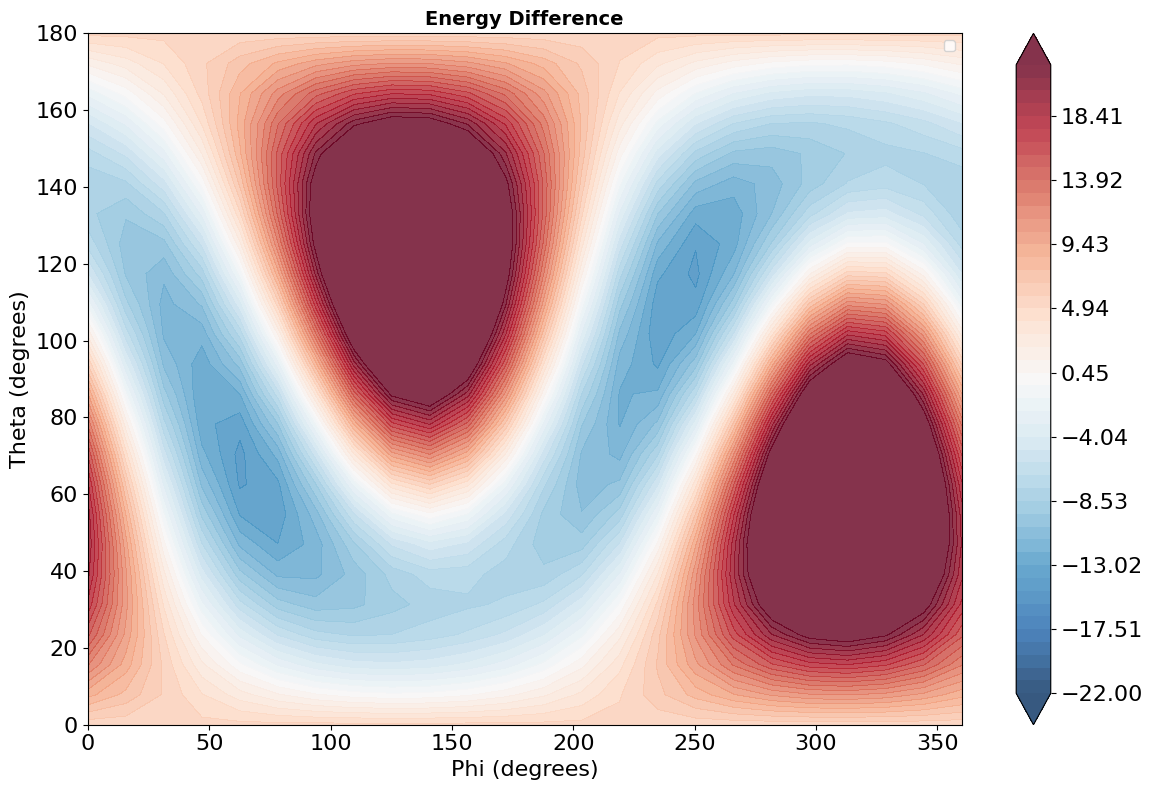


Energy Difference Statistics:
------------------------------------------------------------
Mean difference: 5.479662e+00
Std difference: 1.316025e+01
Max difference: 3.776852e+01
Min difference: -1.422509e+01


In [7]:
def plot_energy_difference(result_a, result_b, subsample=4, min_val=-22, max_val=22, file_name="test.png", fig_title="Energy Difference"):
    """
    Plot energy difference (ortho - meta) with gradient vectors overlaid.
    
    Parameters:
    -----------
    meta_results : dict
        Results from META dataset
    ortho_results : dict
        Results from ORTHO dataset
    subsample : int
        Plot every Nth arrow
    file_name : string
        Name of the file to save plot in
    """
    hartree_to_kcalmol = 627.5094740631
    
    # Calculate energy difference
    energy_diff = (result_a['grid_values'] - result_b['grid_values']) * hartree_to_kcalmol
    
    # Get grids (assuming same grid for both)
    phi_grid = result_a['phi_grid']
    theta_grid = result_a['theta_grid']
    PH, TH = np.meshgrid(phi_grid, theta_grid)
    

    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))

    # 2. Update contourf with vmin, vmax, and explicit levels
    # Adding extend='both' creates pointed ends on the colorbar for values out of range
    levels = np.linspace(min_val, max_val, 50)
    contour = ax.contourf(PH, TH, energy_diff, 
                          levels=levels, 
                          vmin=min_val, 
                          vmax=max_val,
                          cmap='RdBu_r', 
                          alpha=0.8,
                          extend='both')
    
        
    ax.set_xlabel('Phi (degrees)', fontsize=16)
    ax.set_ylabel('Theta (degrees)', fontsize=16)
    ax.set_title(fig_title, fontsize=14, fontweight='bold')
    # Adjust both X and Y axes at once
    ax.tick_params(axis='both', labelsize=16)
    
    # Add colorbar
    #cbar = plt.colorbar(contour, ax=ax, label='Energy Difference (ORTHO - META)')
    # 3. Update the Colorbar formatting
    cbar = plt.colorbar(contour, ax=ax)
    #cbar.set_label('Energy Difference (ORTHO - META)', fontsize=16) # Label size
    cbar.ax.tick_params(labelsize=16) # Value/Tick font size
        
    # Add legend
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(file_name, dpi=200)
    plt.show()
    # Print statistics
    print(f"\nEnergy Difference Statistics:")
    print(f"{'-'*60}")
    print(f"Mean difference: {np.nanmean(energy_diff):.6e}")
    print(f"Std difference: {np.nanstd(energy_diff):.6e}")
    print(f"Max difference: {np.nanmax(energy_diff):.6e}")
    print(f"Min difference: {np.nanmin(energy_diff):.6e}")
    


# Usage examples:

# Overlay ORTHO gradients on difference plot
plot_energy_difference(ortho_results, meta_results, subsample=4, min_val=-22, max_val=22, file_name="test.png", fig_title="Energy Difference")

plot_energy_difference(para_results, meta_results, subsample=4, min_val=-22, max_val=22, file_name="test.png", fig_title="Energy Difference")




In [5]:
def generate_lambda_vec_from_theta_and_phi(theta, phi):
    """ takes theta and phi in degrees and converts to radians 
    """
    # convert to radians
    theta *= np.pi / 180
    phi *= np.pi / 180
    
    # compute x, y, z
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    return [x,y,z]


def get_energy_at_angle(result_a, result_b, theta, phi):
    """
    Return absolute energies, energy difference, and Cartesian unit vector
    for a specific (theta, phi) angle pair.

    Parameters
    ----------
    result_a : dict
        First dataset containing 'grid_values', 'theta_grid', and 'phi_grid'.
    result_b : dict
        Second dataset containing 'grid_values', 'theta_grid', and 'phi_grid'.
    theta : float
        Polar angle in degrees.
    phi : float
        Azimuthal angle in degrees.

    Returns
    -------
    dict with keys:
        'energy_a'      : float  – energy from result_a at (theta, phi) in Hartree
        'energy_b'      : float  – energy from result_b at (theta, phi) in Hartree
        'energy_diff'   : float  – (a - b) energy difference in kcal/mol
        'unit_vector'   : list   – [x, y, z] Cartesian components of the angle pair
        'theta'         : float  – input theta (degrees)
        'phi'           : float  – input phi (degrees)
    """
    hartree_to_kcalmol = 627.5094740631

    # --- find nearest grid indices ---
    theta_grid = result_a['theta_grid']
    phi_grid   = result_a['phi_grid']

    theta_idx = int(np.argmin(np.abs(theta_grid - theta)))
    phi_idx   = int(np.argmin(np.abs(phi_grid   - phi)))

    # --- extract energies ---
    energy_a = result_a['grid_values'][theta_idx, phi_idx]
    energy_b = result_b['grid_values'][theta_idx, phi_idx]
    energy_diff = (energy_a - energy_b) * hartree_to_kcalmol

    # --- compute Cartesian unit vector ---
    unit_vector = generate_lambda_vec_from_theta_and_phi(theta, phi) 

    unit_vector = np.array(unit_vector)
    result = {
        'energy_a'    : energy_a,
        'energy_b'    : energy_b,
        'energy_diff' : energy_diff,
        'unit_vector' : unit_vector,
        'theta'       : theta_grid[theta_idx],   # actual grid point used
        'phi'         : phi_grid[phi_idx],        # actual grid point used
    }

    # --- pretty print ---
    print(f"Angle Query Results")
    print(f"{'─'*45}")
    print(f"  Requested  : theta={theta:.4f}°, phi={phi:.4f}°")
    print(f"  Nearest grid: theta={result['theta']:.4f}°, phi={result['phi']:.4f}°")
    print(f"{'─'*45}")
    print(f"  Energy A       : {energy_a:.10f} Hartree")
    print(f"  Energy B       : {energy_b:.10f} Hartree")
    print(f"  Difference (A-B): {energy_diff:+.6f} kcal/mol")
    print(f"{'─'*45}")
    print(f"  Unit vector [x, y, z]:")
    print(f"    x = {unit_vector[0]:+.6f}")
    print(f"    y = {unit_vector[1]:+.6f}")
    print(f"    z = {unit_vector[2]:+.6f}")

    return result

In [9]:
res_om_a = get_energy_at_angle(ortho_results, meta_results, 74.1, 35.0)
res_pm_a = get_energy_at_angle(para_results, meta_results, 74.1, 35.0)

res_om_b = get_energy_at_angle(ortho_results, meta_results, 74.1, 150.0)
res_pm_b = get_energy_at_angle(para_results, meta_results, 74.1, 150.0)

res_om_c = get_energy_at_angle(ortho_results, meta_results, 120, 150.0)
res_pm_c = get_energy_at_angle(para_results, meta_results, 120, 150.0)

res_om_d = get_energy_at_angle(ortho_results, meta_results, 65, 65.0)
res_pm_d = get_energy_at_angle(para_results, meta_results, 65, 65.0)



# Pack them into the dict the rest of the script expects
res = {
    'om_a': res_om_a, 'pm_a': res_pm_a,
    'om_b': res_om_b, 'pm_b': res_pm_b,
    'om_c': res_om_c, 'pm_c': res_pm_c,
    'om_d': res_om_d, 'pm_d': res_pm_d,
}

Angle Query Results
─────────────────────────────────────────────
  Requested  : theta=74.1000°, phi=35.0000°
  Nearest grid: theta=70.4348°, phi=31.3043°
─────────────────────────────────────────────
  Energy A       : -3007.7979139821 Hartree
  Energy B       : -3007.7609126089 Hartree
  Difference (A-B): -23.218712 kcal/mol
─────────────────────────────────────────────
  Unit vector [x, y, z]:
    x = +0.787812
    y = +0.551632
    z = +0.273959
Angle Query Results
─────────────────────────────────────────────
  Requested  : theta=74.1000°, phi=35.0000°
  Nearest grid: theta=70.4348°, phi=31.3043°
─────────────────────────────────────────────
  Energy A       : -3007.7693934629 Hartree
  Energy B       : -3007.7609126089 Hartree
  Difference (A-B): -5.321816 kcal/mol
─────────────────────────────────────────────
  Unit vector [x, y, z]:
    x = +0.787812
    y = +0.551632
    z = +0.273959
Angle Query Results
─────────────────────────────────────────────
  Requested  : theta=74.100

In [10]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import math

# Your actual results from get_energy_at_angle
res_om_a = get_energy_at_angle(ortho_results, meta_results, 74.1, 35.0)
res_pm_a = get_energy_at_angle(para_results, meta_results, 74.1, 35.0)
res_om_b = get_energy_at_angle(ortho_results, meta_results, 74.1, 150.0)
res_pm_b = get_energy_at_angle(para_results, meta_results, 74.1, 150.0)
res_om_c = get_energy_at_angle(ortho_results, meta_results, 120, 150.0)
res_pm_c = get_energy_at_angle(para_results, meta_results, 120, 150.0)
res_om_d = get_energy_at_angle(ortho_results, meta_results, 65, 65.0)
res_pm_d = get_energy_at_angle(para_results, meta_results, 65, 65.0)

# Pack them into the dict the rest of the script expects
res = {
    'om_a': res_om_a, 'pm_a': res_pm_a,
    'om_b': res_om_b, 'pm_b': res_pm_b,
    'om_c': res_om_c, 'pm_c': res_pm_c,
    'om_d': res_om_d, 'pm_d': res_pm_d,
}
# ── Build workbook ──────────────────────────────────────────────────────────────
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Strong Field Coupling Energies"

# colour palette
HDR_FILL  = PatternFill("solid", start_color="1F3864")   # dark navy
SUB_FILL  = PatternFill("solid", start_color="2E75B6")   # mid blue
GRP_FILLS = [
    PatternFill("solid", start_color="D6E4F0"),  # lightest blue – field a
    PatternFill("solid", start_color="C6EFCE"),  # light green  – field b
    PatternFill("solid", start_color="FFEB9C"),  # light amber  – field c
    PatternFill("solid", start_color="FCE4D6"),  # light peach  – field d
]
HDR_FONT  = Font(name="Arial", bold=True, color="FFFFFF", size=11)
SUB_FONT  = Font(name="Arial", bold=True, color="FFFFFF", size=10)
BODY_FONT = Font(name="Arial", size=10)
LABEL_FONT= Font(name="Arial", bold=True, size=10)

thin  = Side(style="thin",   color="BFBFBF")
thick = Side(style="medium", color="1F3864")
thin_border  = Border(left=thin,  right=thin,  top=thin,  bottom=thin)
thick_border = Border(left=thick, right=thick, top=thick, bottom=thick)

def hcenter(cell):
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

def apply_border(ws, row, col):
    ws.cell(row=row, column=col).border = thin_border

# ── Row 1: main title ───────────────────────────────────────────────────────────
ws.merge_cells("A1:M1")
t = ws["A1"]
t.value = "Strong-Field Coupling — Intermediate Energies by Field Direction"
t.font  = Font(name="Arial", bold=True, size=14, color="1F3864")
t.alignment = Alignment(horizontal="center", vertical="center")
ws.row_dimensions[1].height = 30

# ── Row 2: column headers ───────────────────────────────────────────────────────
headers = [
    "Field\nDir.", "θ (°)", "φ (°)",
    "Fx (unit vec.)", "Fy (unit vec.)", "Fz (unit vec.)",
    "E (ortho) / a.u.", "E (meta) / a.u.", "E (para) / a.u.",
    "ΔE ortho–meta\n/ a.u.", "ΔE para–meta\n/ a.u.",
    "ΔE ortho–meta\n/ kcal mol⁻¹", "ΔE para–meta\n/ kcal mol⁻¹",
]
AU_TO_KCAL = 627.5094  # 1 Hartree = 627.5094 kcal/mol

for c, h in enumerate(headers, start=1):
    cell = ws.cell(row=2, column=c, value=h)
    cell.font = HDR_FONT
    cell.fill = HDR_FILL
    cell.border = thin_border
    hcenter(cell)
ws.row_dimensions[2].height = 36

# ── Data rows ───────────────────────────────────────────────────────────────────
tags  = ['a', 'b', 'c', 'd']
label = {'a': 'A', 'b': 'B', 'c': 'C', 'd': 'D'}

data_start = 3
for i, tag in enumerate(tags):
    r = data_start + i
    om = res[f'om_{tag}']
    pm = res[f'pm_{tag}']

    vec = om['unit_vector']
    row_data = [
        f"Direction {label[tag]}",
        om['theta'],
        om['phi'],
        vec[0], vec[1], vec[2],
        om['energy_a'],          # ortho
        om['energy_b'],          # meta  (same in both dicts)
        pm['energy_a'],          # para
        om['energy_diff'],       # ΔE ortho–meta  (au)
        pm['energy_diff'],       # ΔE para–meta   (au)
        om['energy_diff'] * AU_TO_KCAL,
        pm['energy_diff'] * AU_TO_KCAL,
    ]

    fill = GRP_FILLS[i]
    for c, val in enumerate(row_data, start=1):
        cell = ws.cell(row=r, column=c, value=val)
        cell.font  = BODY_FONT
        cell.fill  = fill
        cell.border = thin_border
        hcenter(cell)
        # number formats
        if c in (2, 3):                    # angles
            cell.number_format = '0.0'
        elif c in (4, 5, 6):               # unit vector components
            cell.number_format = '0.000000'
        elif c in (7, 8, 9, 10, 11):       # energies in a.u.
            cell.number_format = '0.000000'
        elif c in (12, 13):                # energies in kcal/mol
            cell.number_format = '0.00'

    # bold the direction label
    ws.cell(row=r, column=1).font = Font(name="Arial", bold=True, size=10)

ws.row_dimensions[data_start].height = 18

# ── Column widths ───────────────────────────────────────────────────────────────
col_widths = [14, 9, 9, 16, 16, 16, 20, 20, 20, 22, 22, 22, 22]
for c, w in enumerate(col_widths, start=1):
    ws.column_dimensions[get_column_letter(c)].width = w

# ── Freeze header rows ──────────────────────────────────────────────────────────
ws.freeze_panes = "A3"

wb.save("strong_field_energies.xlsx")
print("Saved.")

Angle Query Results
─────────────────────────────────────────────
  Requested  : theta=74.1000°, phi=35.0000°
  Nearest grid: theta=70.4348°, phi=31.3043°
─────────────────────────────────────────────
  Energy A       : -3007.7979139821 Hartree
  Energy B       : -3007.7609126089 Hartree
  Difference (A-B): -23.218712 kcal/mol
─────────────────────────────────────────────
  Unit vector [x, y, z]:
    x = +0.787812
    y = +0.551632
    z = +0.273959
Angle Query Results
─────────────────────────────────────────────
  Requested  : theta=74.1000°, phi=35.0000°
  Nearest grid: theta=70.4348°, phi=31.3043°
─────────────────────────────────────────────
  Energy A       : -3007.7693934629 Hartree
  Energy B       : -3007.7609126089 Hartree
  Difference (A-B): -5.321816 kcal/mol
─────────────────────────────────────────────
  Unit vector [x, y, z]:
    x = +0.787812
    y = +0.551632
    z = +0.273959
Angle Query Results
─────────────────────────────────────────────
  Requested  : theta=74.100